In [2]:
from preprocessing.file_conversion import file_conversion
import numpy as np
import pandas as pd
from scipy.stats import kruskal
import matplotlib.pyplot as plt
import seaborn as sns 
#path = "/Users/reymendoza/Desktop/sleep_files"
#X, y, groups = file_conversion(path)

#np.savez_compressed("sleep_dataset.npz", X=X, y=y, groups=groups)

data = np.load("/Users/reymendoza/Developer/Sleep-Stage-Classification/sleep_dataset_16.npz", allow_pickle=True)
X = data["X"]
y = data["y"]
groups = data["groups"]

In [3]:
X[4000]

array([-1.00454979e+01, -1.07705765e+01, -1.11445084e+01, -1.11575851e+01,
       -1.13996706e+01,  7.35227227e-01,  1.31764561e-01,  5.09356000e-02,
        4.91799861e-02,  2.46366318e-02,  7.20229864e-01,  1.09416163e+00,
        3.47538710e-01,  1.10723770e+00, -5.21625094e-02,  2.64467048e-09,
        2.00758860e-01,  1.15330362e+01,  5.22551012e+00], dtype=float32)

In [4]:
feature_columns = [
    "delta_abs_bandpower",
    "theta_abs_bandpower",
    "alpha_abs_bandpower",
    "beta_abs_bandpower",
    "gamma_abs_bandpower",
    "delta_rel_bandpower",
    "theta_rel_bandpower",
    "alpha_rel_bandpower",
    "beta_rel_bandpower",
    "gamma_rel_bandpower",
    "delta_theta_ratio",
    "delta_alpha_ratio",
    "theta_alpha_ratio",
    "delta_beta_ratio",
    "alpha_beta_ratio",
    "hjorth_activity",
    "hjorth_mobility",
    "hjorth_complexity",
    "spectral_entropy",
]
feature_df = pd.DataFrame(X, columns=feature_columns)
feature_df['label'] = y
feature_df['label'] = feature_df['label'].replace({1: 'Awake', 2: 'REM', 3: 'N1', 4: 'N2', 5: 'N3'})
feature_df['group'] = groups
#feature_df = feature_df.dropna()

In [5]:
feature_df['group'].unique()

<StringArray>
['sub-001', 'sub-002', 'sub-003', 'sub-004', 'sub-005', 'sub-006', 'sub-007',
 'sub-008', 'sub-009', 'sub-010', 'sub-011', 'sub-012', 'sub-014', 'sub-016']
Length: 14, dtype: str

In [6]:
feature_df

,delta_abs_bandpower,theta_abs_bandpower,alpha_abs_bandpower,beta_abs_bandpower,gamma_abs_bandpower,delta_rel_bandpower,theta_rel_bandpower,alpha_rel_bandpower,beta_rel_bandpower,gamma_rel_bandpower,...,delta_alpha_ratio,theta_alpha_ratio,delta_beta_ratio,alpha_beta_ratio,hjorth_activity,hjorth_mobility,hjorth_complexity,spectral_entropy,label,group
0,-9.330526,-9.911626,-10.128387,-10.094761,-10.224792,0.582613,0.151934,9.174319e-02,9.922940e-02,0.073231,...,0.796930,0.213203,0.763304,-0.039502,3.433390e-09,0.225883,6.668432,5.680030,Awake,sub-001
1,-9.682848,-10.223487,-10.345713,-10.376105,-10.550993,0.545554,0.155228,1.165025e-01,1.084498e-01,0.071625,...,0.660767,0.114899,0.691159,0.020657,7.481646e-09,0.167238,9.542396,5.414741,Awake,sub-001
2,-9.629116,-9.989437,-10.358152,-10.185108,-10.404510,0.485375,0.210548,8.889394e-02,1.334246e-01,0.079684,...,0.727183,0.364456,0.554139,-0.183066,2.680533e-09,0.243390,6.167042,6.409827,Awake,sub-001
3,-9.771422,-10.089672,-10.311217,-10.234983,-10.345598,0.421949,0.201470,1.199648e-01,1.434651e-01,0.110643,...,0.537222,0.216173,0.460988,-0.085218,5.844341e-09,0.241012,7.201754,5.039212,Awake,sub-001
4,-8.954587,-7.817912,-8.688139,-8.975296,-9.286588,0.055626,0.762638,1.027798e-01,5.303374e-02,0.025872,...,-0.266839,0.870199,0.020318,0.286945,6.173166e-07,0.150321,14.234574,4.640651,Awake,sub-001
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13634,-5.596910,-5.745661,-6.036495,-6.082315,-6.301124,0.384905,0.273276,1.398841e-01,1.258774e-01,0.076057,...,0.439585,0.290833,0.485405,0.045820,7.675954e-05,0.123625,19.464575,4.993173,Awake,sub-016
13635,-4.253548,-4.799256,-5.475278,-5.461412,-5.862738,0.698709,0.198879,4.193405e-02,4.329446e-02,0.017183,...,1.221730,0.676022,1.207864,-0.013866,6.916565e-04,0.059672,23.906750,2.816214,Awake,sub-016
13636,-11.999619,-11.999991,-11.999999,-12.000000,-11.797678,0.000550,0.000013,8.877466e-07,2.425662e-07,0.372198,...,-3.057445,-4.698722,-3.057445,-5.849144,2.398332e-09,0.430812,13.964173,1.083310,Awake,sub-016
13637,-11.744497,-11.994123,-11.999272,-11.999737,-11.658466,0.265889,0.004522,5.564531e-04,2.015985e-04,0.396865,...,-0.097120,-1.866465,-0.096656,-2.775928,5.652022e-06,0.520471,31.528048,0.845432,Awake,sub-016


##### sub-008 appears to have all epochs with NaNs

In [7]:
feature_df.groupby("group").apply(lambda x: x.isna().any(axis=1).sum())

group
sub-001    0
sub-002    0
sub-003    0
sub-004    0
sub-005    0
sub-006    0
sub-007    0
sub-008    0
sub-009    0
sub-010    0
sub-011    0
sub-012    0
sub-014    0
sub-016    0
dtype: int64

In [8]:
feature_df['group'].value_counts()

group
sub-003    1068
sub-011    1038
sub-007    1035
sub-012    1030
sub-005    1028
sub-008    1013
sub-004    1006
sub-010     989
sub-009     977
sub-014     973
sub-006     962
sub-001     942
sub-002     888
sub-016     690
Name: count, dtype: int64

#### __Label Distributions__
##### N2 sleep makes the majority of the sleep epochs, followed by REM, Awake, N3 (deep) sleep, and N1 sleep (the lowest proportion)

In [9]:
print(feature_df['label'].value_counts())
print(feature_df['label'].value_counts(normalize=True))

label
N2       5992
REM      2283
N3       2223
Awake    2015
N1       1126
Name: count, dtype: int64
label
N2       0.439328
REM      0.167388
N3       0.162988
Awake    0.147738
N1       0.082557
Name: proportion, dtype: float64


#### __Label Distributions__
##### N2 sleep makes the majority of the sleep epochs, followed by REM, Awake, N3 (deep) sleep, and N1 sleep (the lowest proportion)

In [10]:
# Calculating feature variance to ensure no static feature
numeric_df = feature_df.select_dtypes(include=[np.number]).drop(columns=["label", "group"], errors="ignore")
numeric_df = numeric_df.dropna()

summary = pd.DataFrame({
    "mean": numeric_df.mean(),
    "std": numeric_df.std(),
    "var": numeric_df.var()
})

summary["coef_var"] = summary["std"] / summary["mean"].abs()
summary = summary.sort_values("var")

print(summary)

                          mean        std           var   coef_var
hjorth_activity       0.000001   0.000026  6.796131e-10  19.589231
alpha_rel_bandpower   0.082250   0.047019  2.210819e-03   0.571663
beta_rel_bandpower    0.084877   0.063851  4.076908e-03   0.752273
theta_rel_bandpower   0.163709   0.076841  5.904494e-03   0.469373
gamma_rel_bandpower   0.056543   0.088191  7.777683e-03   1.559729
hjorth_mobility       0.154223   0.135642  1.839882e-02   0.879522
delta_rel_bandpower   0.590771   0.163511  2.673583e-02   0.276775
alpha_beta_ratio     -0.108089   0.658333  4.334026e-01   6.090651
theta_alpha_ratio     0.202684   0.660579  4.363642e-01   3.259163
delta_theta_ratio     0.502485   0.705004  4.970309e-01   1.403035
delta_alpha_ratio     0.786274   0.757613  5.739775e-01   0.963548
delta_beta_ratio      0.803050   0.784311  6.151438e-01   0.976665
gamma_abs_bandpower -10.958337   0.983638  9.675431e-01   0.089762
beta_abs_bandpower  -10.732831   1.038072  1.077594e+00   0.09

In [11]:
# Discovering features that discriminate any label well
df = feature_df.copy()
numeric_df = df.select_dtypes(include=[np.number]).drop(columns=["group"], errors="ignore")
numeric_df = numeric_df.dropna()
df = df.loc[numeric_df.index].copy()

results = []

for feature in numeric_df.columns:
    groups = [
        df.loc[df["label"] == cls, feature].dropna().values
        for cls in sorted(df["label"].unique())
    ]
    
    stat, p = kruskal(*groups)
    results.append({
        "feature": feature,
        "kruskal_stat": stat,
        "p_value": p
    })

results_df = pd.DataFrame(results).sort_values("p_value")
print(results_df)

                feature  kruskal_stat  p_value
0   delta_abs_bandpower   1500.273438      0.0
16      hjorth_mobility    565.765625      0.0
15      hjorth_activity   1764.601562      0.0
14     alpha_beta_ratio    780.628906      0.0
13     delta_beta_ratio   2183.898438      0.0
12    theta_alpha_ratio   1061.773438      0.0
11    delta_alpha_ratio   2330.003906      0.0
10    delta_theta_ratio   2477.589844      0.0
17    hjorth_complexity    565.246094      0.0
9   gamma_rel_bandpower   1269.652344      0.0
7   alpha_rel_bandpower   1447.343750      0.0
6   theta_rel_bandpower   1736.718750      0.0
5   delta_rel_bandpower   1936.933594      0.0
4   gamma_abs_bandpower   1719.183594      0.0
3    beta_abs_bandpower   1172.824219      0.0
2   alpha_abs_bandpower    922.699219      0.0
1   theta_abs_bandpower    896.078125      0.0
8    beta_rel_bandpower   1409.210938      0.0
18     spectral_entropy   1059.257812      0.0


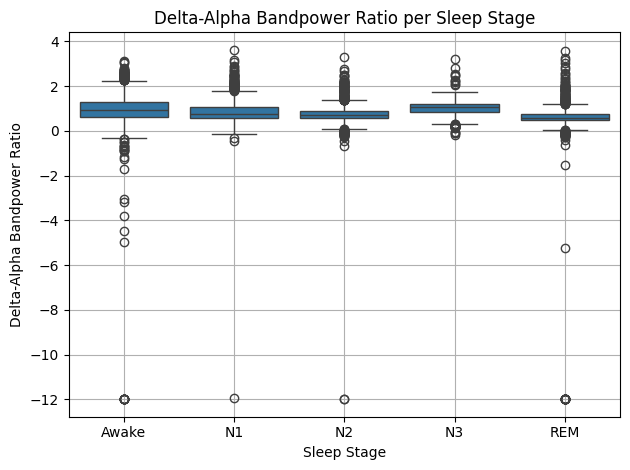

In [12]:
# Delta-Alpha Ratio vs Sleep Stage
sns.boxplot(feature_df, x='label', y='delta_alpha_ratio')
plt.title('Delta-Alpha Bandpower Ratio per Sleep Stage')
plt.xlabel('Sleep Stage')
plt.ylabel('Delta-Alpha Bandpower Ratio')
plt.grid()
plt.tight_layout()

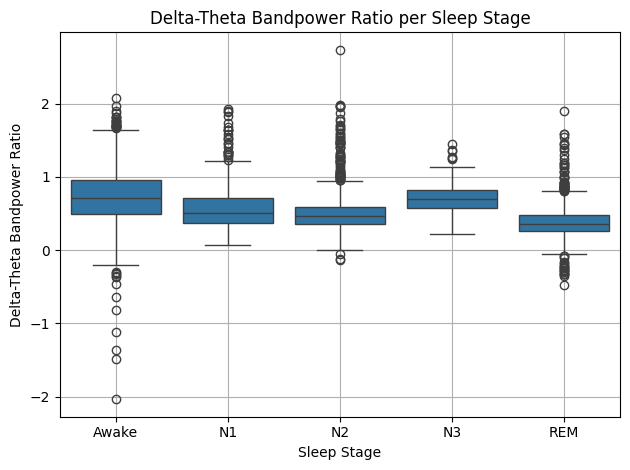

In [ ]:
# Delta-Theta Ratio vs Sleep Stage
sns.boxplot(feature_df, x='label', y='delta_theta_ratio')
plt.title('Delta-Theta Bandpower Ratio per Sleep Stage')
plt.xlabel('Sleep Stage')
plt.ylabel('Delta-Theta Bandpower Ratio')
plt.grid()
plt.tight_layout()

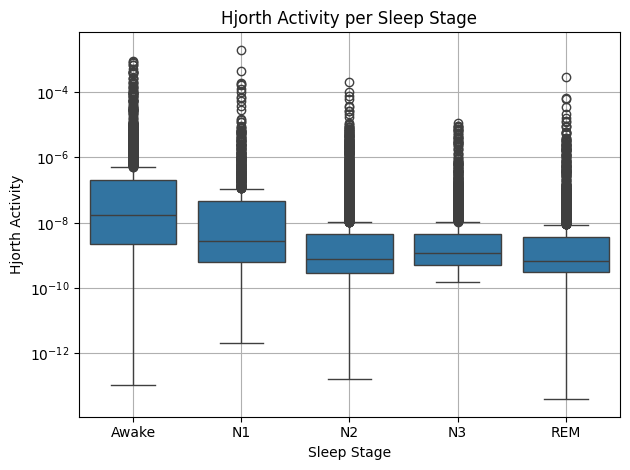

In [13]:
# Hjorth Activity vs Sleep Stage
sns.boxplot(feature_df, x='label', y='hjorth_activity') # log scaled
plt.title('Hjorth Activity per Sleep Stage')
plt.xlabel('Sleep Stage')
plt.ylabel('Hjorth Activity')
plt.yscale('log')
plt.grid()
plt.tight_layout()

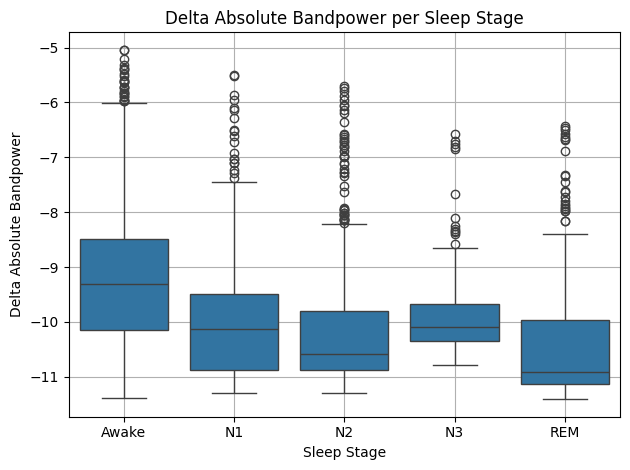

In [ ]:
# Delta Absolute Bandpower vs Sleep Stage
sns.boxplot(feature_df, x='label', y='delta_abs_bandpower')
plt.title('Delta Absolute Bandpower per Sleep Stage')
plt.xlabel('Sleep Stage')
plt.ylabel('Delta Absolute Bandpower')
plt.grid()
plt.tight_layout()

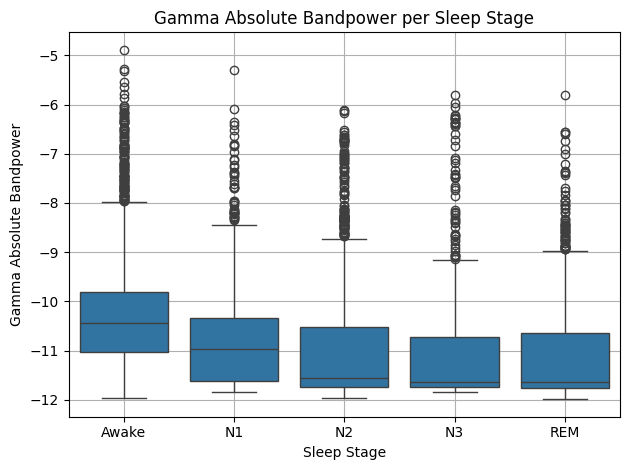

In [14]:
# Gamma Absolute Bandpower vs Sleep Stage
sns.boxplot(feature_df, x='label', y='gamma_abs_bandpower')
plt.title('Gamma Absolute Bandpower per Sleep Stage')
plt.xlabel('Sleep Stage')
plt.ylabel('Gamma Absolute Bandpower')
plt.grid()
plt.tight_layout()

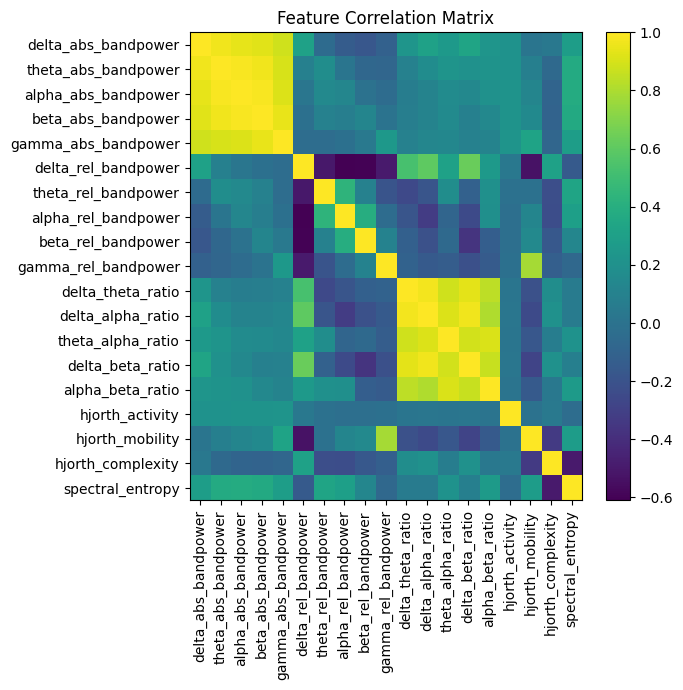

In [15]:
# Correlation Matrix
numeric_df = feature_df.select_dtypes(include=[np.number]).copy()
cols_to_drop = [col for col in ["label", "group"] if col in numeric_df.columns]
numeric_df = numeric_df.drop(columns=cols_to_drop, errors="ignore")

# Drop rows with NaNs so correlations are not distorted
numeric_df = numeric_df.dropna()

# Compute correlation matrix
corr_matrix = numeric_df.corr(method="pearson")

# Plot
plt.figure(figsize=(7, 7))
im = plt.imshow(corr_matrix, interpolation="nearest", aspect="auto")
plt.colorbar(im)
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()